# Homework 10

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.preprocessing import MinMaxScaler, StandardScaler, Normalizer
from sklearn.mixture import GaussianMixture

# Налаштування відображення
%matplotlib inline

## 1. Завантаження даних

In [3]:
from urllib.request import urlretrieve
import zipfile
import os
dataset_url = "https://github.com/goitacademy/NUMERICAL-PROGRAMMING-IN-PYTHON/raw/main/WorldHappinessReport.zip"
zip_file_path = "WorldHappinessReport.zip"
download_path = "./happiness-report-data/"

if not os.path.exists(download_path):
    print("Завантаження датасету...")
    try:
        urlretrieve(dataset_url, zip_file_path)
        with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
            zip_ref.extractall(download_path)
        os.remove(zip_file_path)
        print("Датасет завантажено та розархівовано.")
    except Exception as e:
        print(f"Помилка при завантаженні: {e}")
else:
    print("Датасет вже завантажено.")


Датасет вже завантажено.


In [4]:
df_file_path = os.path.join(download_path, "2017.csv")
if os.path.exists(df_file_path):
    data = pd.read_csv(df_file_path)
    print("Інформація про датафрейм:")
    data.info()
    print("\nОписова статистика:")
    display(data.describe())

Інформація про датафрейм:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 155 entries, 0 to 154
Data columns (total 12 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Country                        155 non-null    object 
 1   Happiness.Rank                 155 non-null    int64  
 2   Happiness.Score                155 non-null    float64
 3   Whisker.high                   155 non-null    float64
 4   Whisker.low                    155 non-null    float64
 5   Economy..GDP.per.Capita.       155 non-null    float64
 6   Family                         155 non-null    float64
 7   Health..Life.Expectancy.       155 non-null    float64
 8   Freedom                        155 non-null    float64
 9   Generosity                     155 non-null    float64
 10  Trust..Government.Corruption.  155 non-null    float64
 11  Dystopia.Residual              155 non-null    float64
dtypes: float64(10), int64(1)

,Happiness.Rank,Happiness.Score,Whisker.high,Whisker.low,Economy..GDP.per.Capita.,Family,Health..Life.Expectancy.,Freedom,Generosity,Trust..Government.Corruption.,Dystopia.Residual
count,155.000000,155.000000,155.000000,155.000000,155.000000,155.000000,155.000000,155.000000,155.000000,155.000000,155.000000
mean,78.000000,5.354019,5.452326,5.255713,0.984718,1.188898,0.551341,0.408786,0.246883,0.123120,1.850238
std,44.888751,1.131230,1.118542,1.145030,0.420793,0.287263,0.237073,0.149997,0.134780,0.101661,0.500028
min,1.000000,2.693000,2.864884,2.521116,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.377914
25%,39.500000,4.505500,4.608172,4.374955,0.663371,1.042635,0.369866,0.303677,0.154106,0.057271,1.591291
50%,78.000000,5.279000,5.370032,5.193152,1.064578,1.253918,0.606042,0.437454,0.231538,0.089848,1.832910
75%,116.500000,6.101500,6.194600,6.006527,1.318027,1.414316,0.723008,0.516561,0.323762,0.153296,2.144654
max,155.000000,7.537000,7.622030,7.479556,1.870766,1.610574,0.949492,0.658249,0.838075,0.464308,3.117485


In [5]:
data.head()

,Country,Happiness.Rank,Happiness.Score,Whisker.high,Whisker.low,Economy..GDP.per.Capita.,Family,Health..Life.Expectancy.,Freedom,Generosity,Trust..Government.Corruption.,Dystopia.Residual
0,Norway,1,7.537,7.594445,7.479556,1.616463,1.533524,0.796667,0.635423,0.362012,0.315964,2.277027
1,Denmark,2,7.522,7.581728,7.462272,1.482383,1.551122,0.792566,0.626007,0.355280,0.400770,2.313707
2,Iceland,3,7.504,7.622030,7.385970,1.480633,1.610574,0.833552,0.627163,0.475540,0.153527,2.322715
3,Switzerland,4,7.494,7.561772,7.426227,1.564980,1.516912,0.858131,0.620071,0.290549,0.367007,2.276716
4,Finland,5,7.469,7.527542,7.410458,1.443572,1.540247,0.809158,0.617951,0.245483,0.382612,2.430182


## 2. Візуалізація даних

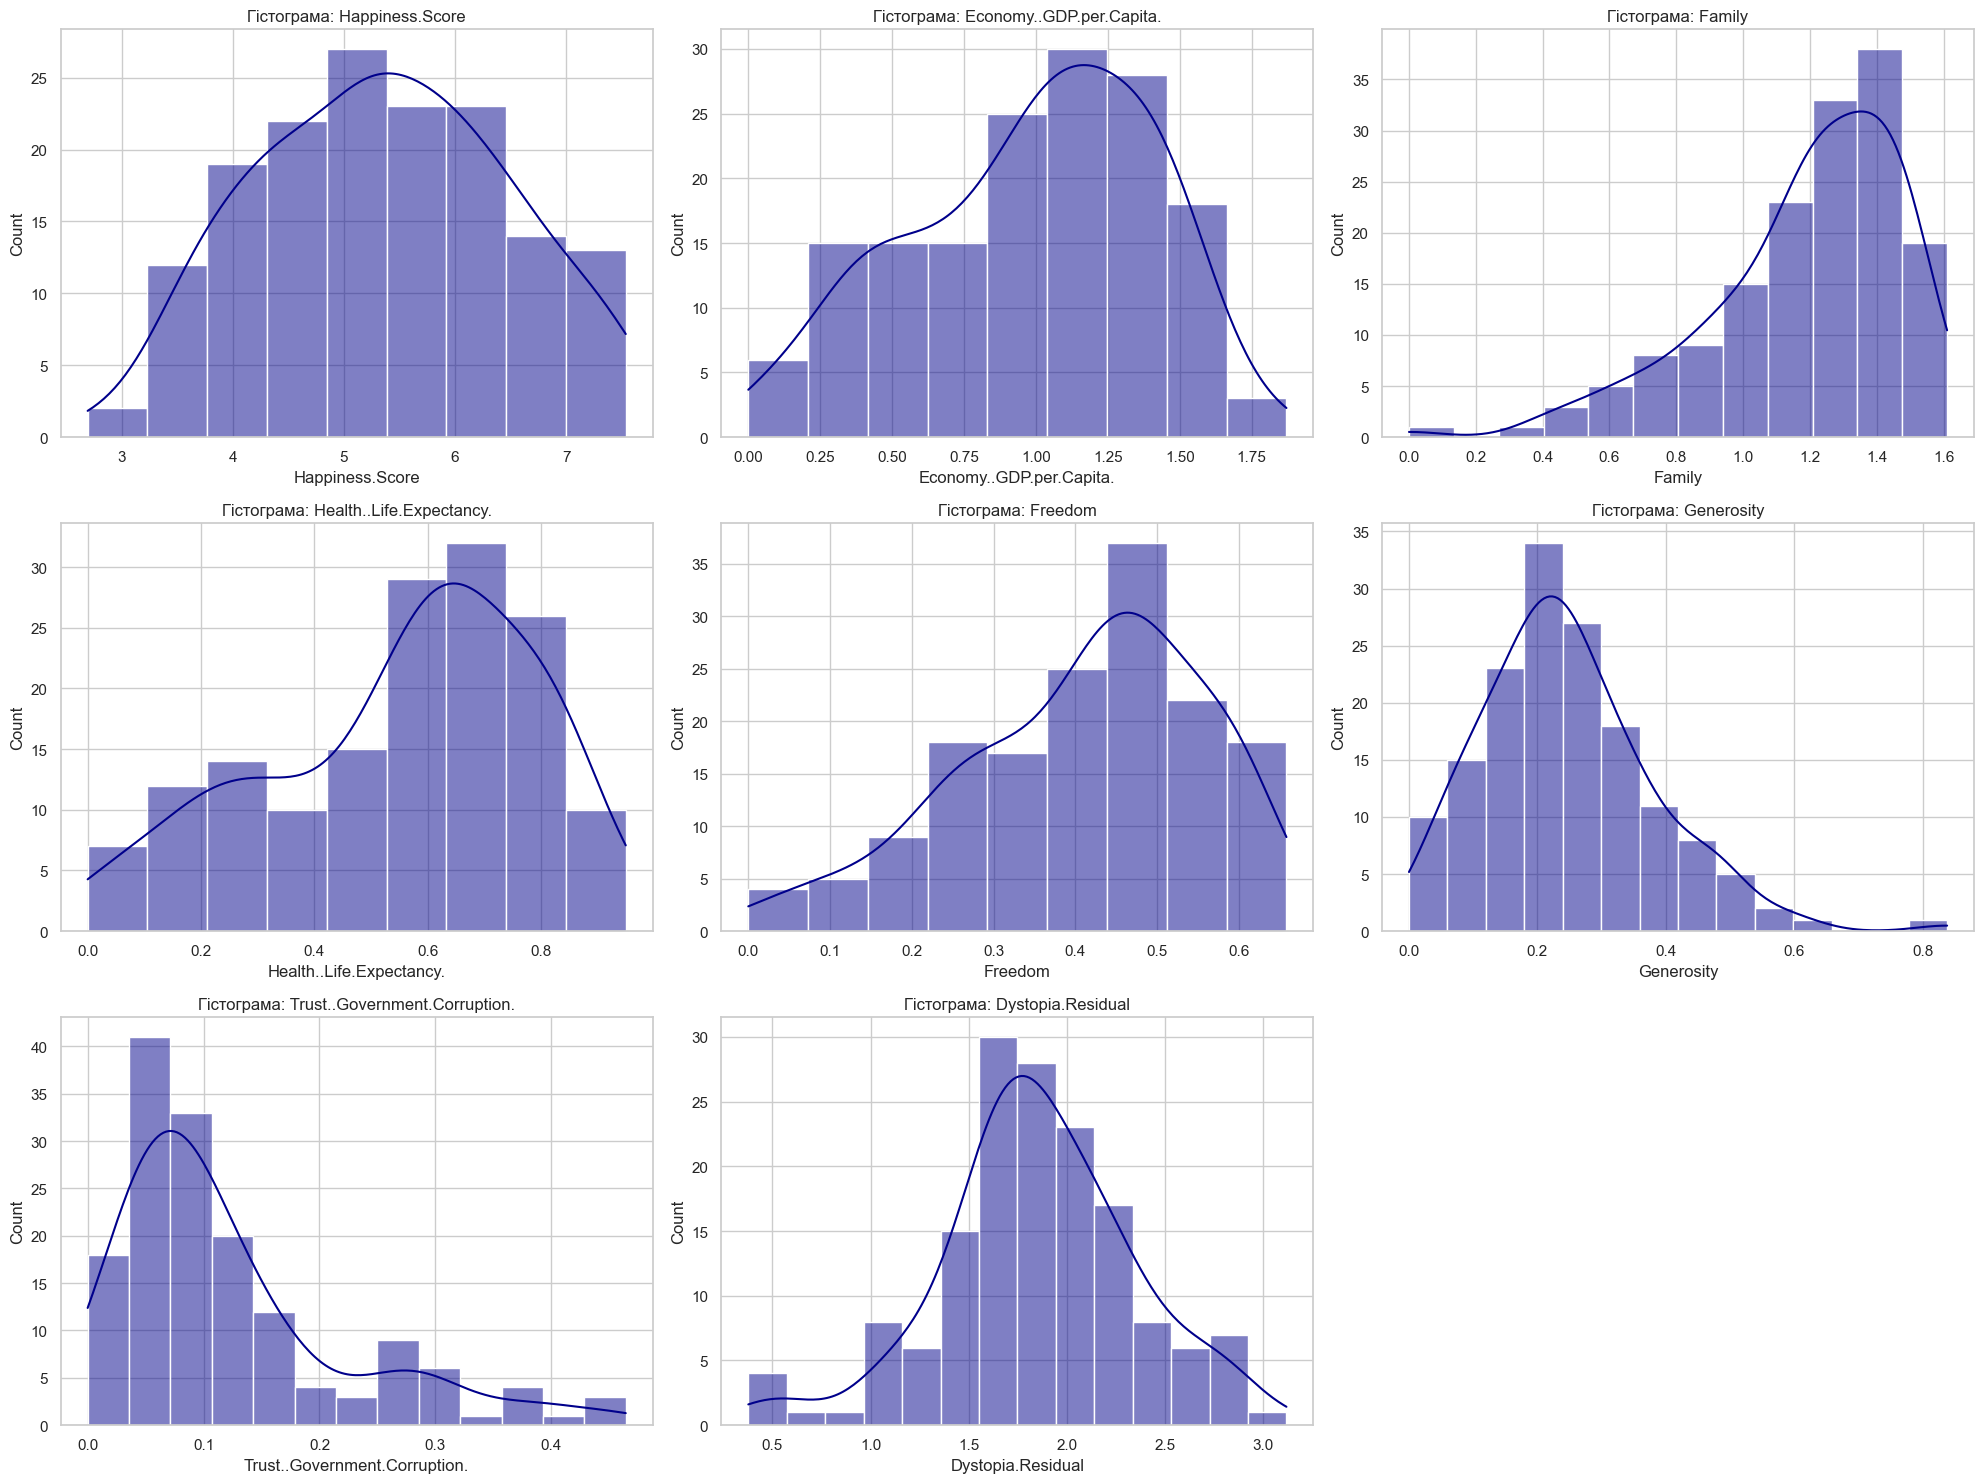

In [ ]:
numeric_cols = [
    'Happiness.Score', 'Economy..GDP.per.Capita.', 'Family',
    'Health..Life.Expectancy.', 'Freedom', 'Generosity',
    'Trust..Government.Corruption.', 'Dystopia.Residual'
]

plt.figure(figsize=(20, 15))
for i, col in enumerate(numeric_cols):
    plt.subplot(3, 3, i + 1)
    sns.histplot(data[col], kde=True, color='darkblue')
    plt.title(f'Гістограма: {col}')
    plt.xlabel(col)

plt.tight_layout()
plt.show()

Примітка: діаграми показують схожість (та не відповідність) з нормальним розподілом, подекуди зі значними зміщеннями.

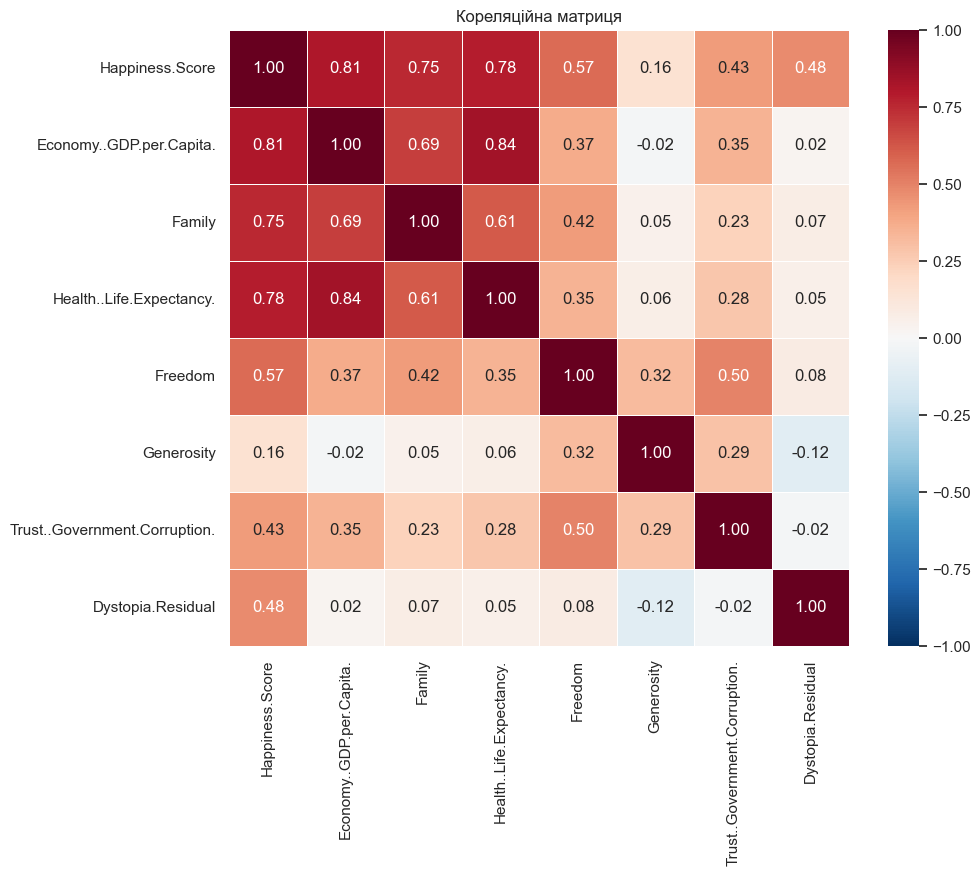

In [7]:
numeric_cols = [
    'Happiness.Score', 'Economy..GDP.per.Capita.', 'Family',
    'Health..Life.Expectancy.', 'Freedom', 'Generosity',
    'Trust..Government.Corruption.', 'Dystopia.Residual'
]
corr_matrix = data[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='RdBu_r', vmin=-1, vmax=1, linewidths=0.5)
plt.title("Кореляційна матриця")
plt.show()

In [8]:
corr_matrix

,Happiness.Score,Economy..GDP.per.Capita.,Family,Health..Life.Expectancy.,Freedom,Generosity,Trust..Government.Corruption.,Dystopia.Residual
Happiness.Score,1.000000,0.812469,0.752737,0.781951,0.570137,0.155256,0.429080,0.475355
Economy..GDP.per.Capita.,0.812469,1.000000,0.688296,0.843077,0.369873,-0.019011,0.350944,0.024226
Family,0.752737,0.688296,1.000000,0.612080,0.424966,0.051693,0.231841,0.070506
Health..Life.Expectancy.,0.781951,0.843077,0.612080,1.000000,0.349827,0.063191,0.279752,0.054963
Freedom,0.570137,0.369873,0.424966,0.349827,1.000000,0.316083,0.499183,0.081926
Generosity,0.155256,-0.019011,0.051693,0.063191,0.316083,1.000000,0.294159,-0.116627
Trust..Government.Corruption.,0.429080,0.350944,0.231841,0.279752,0.499183,0.294159,1.000000,-0.022755
Dystopia.Residual,0.475355,0.024226,0.070506,0.054963,0.081926,-0.116627,-0.022755,1.000000


Примітка: найбільший вплив на Score - від змінних Economy, Family, Health, Freedom

In [9]:
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

fig = px.choropleth(data,
                    locations = "Country",
                    color = "Happiness.Score",
                    locationmode = "country names",
                    color_continuous_scale="turbo",
                    projection="natural earth"
                    )
fig.update_layout(title = "Happiness Index 2017")
fig.show()

warnings.filterwarnings("default", category=DeprecationWarning)

## 3. Стандартизація

In [10]:
def data_scale(data, scaler_type='minmax'):
    from sklearn.preprocessing import MinMaxScaler, StandardScaler, Normalizer
    if scaler_type == 'minmax':
        scaler = MinMaxScaler()
    if scaler_type == 'std':
        scaler = StandardScaler()
    if scaler_type == 'norm':
        scaler = Normalizer()

    scaler.fit(data)
    res = scaler.transform(data)
    return res

# вибираємо числові колонки, окрім колонок з рейтингом
features_to_scale = data.select_dtypes(include=[np.number]).drop(['Happiness.Score', 'Happiness.Rank', 'Whisker.high', 'Whisker.low'], axis=1)

data_scaled = data_scale(features_to_scale, scaler_type='std')

cols = features_to_scale.columns
df_scaled = pd.DataFrame(data_scaled, columns=cols)

print("Перші 5 рядків стандартизованих даних:")
df_scaled.head()

Перші 5 рядків стандартизованих даних:


,Economy..GDP.per.Capita.,Family,Health..Life.Expectancy.,Freedom,Generosity,Trust..Government.Corruption.,Dystopia.Residual
0,1.506188,1.203577,1.038167,1.515836,0.856964,1.903084,0.856296
1,1.186518,1.265036,1.020812,1.452859,0.806856,2.739998,0.929891
2,1.182345,1.472669,1.194259,1.460590,1.702013,0.300066,0.947964
3,1.383442,1.145561,1.298272,1.413155,0.325028,2.406809,0.855673
4,1.093985,1.227057,1.091026,1.398978,-0.010426,2.560800,1.163581


In [11]:
print("Оригінальні середні:\n", features_to_scale.mean())
print("\nСтандартизовані середні (мають бути ~0):\n", df_scaled.mean())
print("\nСтандартизовані відхилення (мають бути ~1):\n", df_scaled.std())

Оригінальні середні:
 Economy..GDP.per.Capita.         0.984718
Family                           1.188898
Health..Life.Expectancy.         0.551341
Freedom                          0.408786
Generosity                       0.246883
Trust..Government.Corruption.    0.123120
Dystopia.Residual                1.850238
dtype: float64

Стандартизовані середні (мають бути ~0):
 Economy..GDP.per.Capita.        -2.750488e-16
Family                           3.667317e-16
Health..Life.Expectancy.        -2.292073e-16
Freedom                          2.750488e-16
Generosity                       1.203339e-16
Trust..Government.Corruption.   -9.168293e-17
Dystopia.Residual                1.375244e-16
dtype: float64

Стандартизовані відхилення (мають бути ~1):
 Economy..GDP.per.Capita.         1.003241
Family                           1.003241
Health..Life.Expectancy.         1.003241
Freedom                          1.003241
Generosity                       1.003241
Trust..Government.Corruption.    

Примітка: Після StandardScaler середнє значення (mean) для всіх колонок стало наближеним до 0, а стандартне відхилення (std) до 1. Це вирівнює вагу ознак.

## 4. Кластерізація.

In [12]:
def doGMM(X, nclust=5):
    model = GaussianMixture(n_components=nclust, init_params='kmeans', random_state=42)
    model.fit(X)
    return model.predict(X)

cluster_labels = doGMM(df_scaled, 5)
data['GMM_Cluster'] = cluster_labels

print("Розподіл країн по кластерах:")
print(data['GMM_Cluster'].value_counts())

Розподіл країн по кластерах:
GMM_Cluster
0    40
4    39
3    35
2    27
1    14
Name: count, dtype: int64


In [13]:
warnings.filterwarnings("ignore", category=DeprecationWarning)
fig_clusters = px.choropleth(data,
                             locations="Country",
                             color="GMM_Cluster",
                             locationmode="country names",
                             color_discrete_sequence=px.colors.qualitative.Safe,
                             projection="natural earth"
                            )
fig_clusters.update_layout(title = "Розподіл країн за кластерами (GMM)")
fig_clusters.show()

warnings.filterwarnings("default", category=DeprecationWarning)

## 5. Вплив на кластерізацію

In [18]:
# Вибір факторів впливу

# subset_cols = ['Economy..GDP.per.Capita.', 'Family', 'Health..Life.Expectancy.', 'Freedom']
subset_cols_v2 = ['Economy..GDP.per.Capita.', 'Family', 'Health..Life.Expectancy.', 'Freedom', 'Trust..Government.Corruption.']
subset_scaled = data_scale(data[subset_cols_v2], scaler_type='std')

cluster_labels = doGMM(subset_scaled, 5)
data['Cluster_Subset'] = cluster_labels

print("Розподіл країн по кластерах:")
print(data['Cluster_Subset'].value_counts())

warnings.filterwarnings("ignore", category=DeprecationWarning)
fig_clusters = px.choropleth(data,
                             locations="Country",
                             color="Cluster_Subset",
                             locationmode="country names",
                             color_discrete_sequence=px.colors.qualitative.Safe,
                             projection="natural earth"
                            )
fig_clusters.update_layout(title = "Кластеризація лише за обраними показниками")
fig_clusters.show()

warnings.filterwarnings("default", category=DeprecationWarning)

Розподіл країн по кластерах:
Cluster_Subset
2    45
1    41
3    31
4    28
0    10
Name: count, dtype: int64


## 6. Порівняння і висновок

Зрупуємо дані за кластером (для GMM_Cluster - як за повним набором ознак, і окремо для Cluster_Subset - за обраними ознаками) і подивимось на статистику Happiness.Score. Порівняємо в обох випадках, чи справді в один кластер потрапили найщасливіші, а в інший - найнещасніші

------------------------------
Модель 1: ПОВНИЙ набір ознак


,count,mean,std
GMM_Cluster,,,
2,27,6.846111,0.562634
0,40,6.009675,0.528295
3,35,5.213714,0.530300
1,14,4.504429,0.610859
4,39,4.079462,0.563991


------------------------------
Модель 2: СКОРОЧЕНИЙ набір (GDP, Family, Health, Freedom, Trust)


,count,mean,std
Cluster_Subset,,,
4,28,6.807107,0.595746
2,45,5.881511,0.604048
3,31,5.112484,0.599264
0,10,4.897700,0.713270
1,41,4.076634,0.584132


C:\Users\elija\AppData\Local\Temp\ipykernel_23856\2073754550.py:16: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


C:\Users\elija\AppData\Local\Temp\ipykernel_23856\2073754550.py:22: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




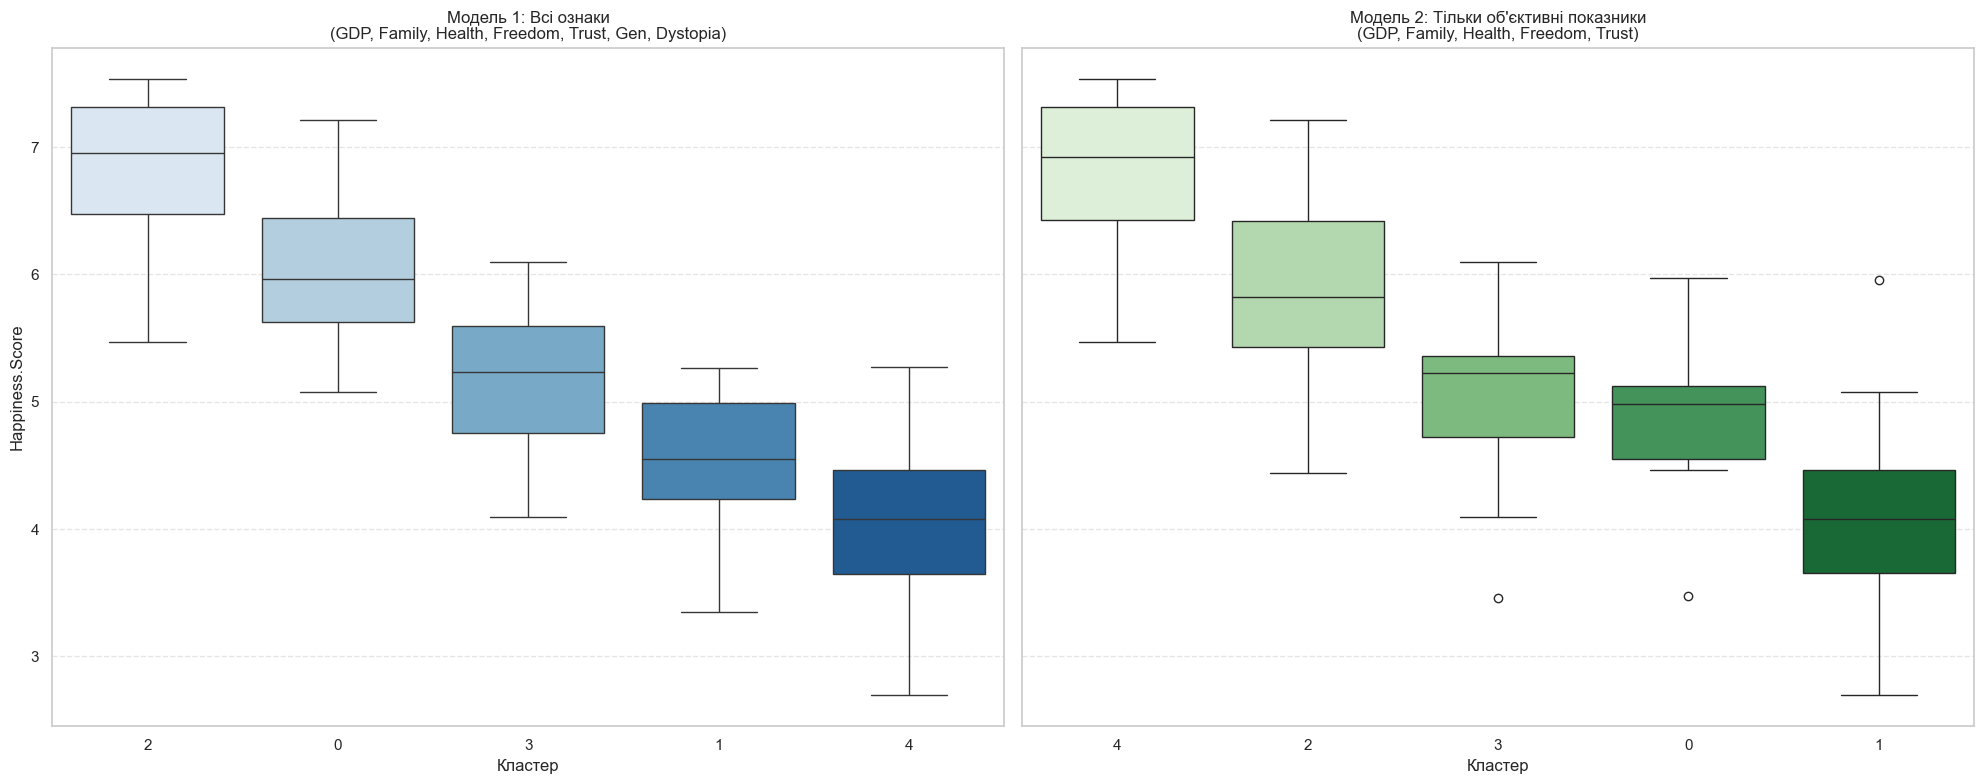

In [20]:
# 1. Виведення табличної статистики
print("-" * 30)
print("Модель 1: ПОВНИЙ набір ознак")
stats_full = data.groupby('GMM_Cluster')['Happiness.Score'].agg(['count', 'mean', 'std']).sort_values(by='mean', ascending=False)
display(stats_full)

print("-" * 30)
print("Модель 2: СКОРОЧЕНИЙ набір (GDP, Family, Health, Freedom, Trust)")
stats_subset = data.groupby('Cluster_Subset')['Happiness.Score'].agg(['count', 'mean', 'std']).sort_values(by='mean', ascending=False)
display(stats_subset)

# 2. Візуальне порівняння (два графіки поруч)
fig, axes = plt.subplots(1, 2, figsize=(20, 8), sharey=True)

# Графік для повного набору
sns.boxplot(ax=axes[0], x='GMM_Cluster', y='Happiness.Score', data=data, order=stats_full.index, palette='Blues')
axes[0].set_title('Модель 1: Всі ознаки\n(GDP, Family, Health, Freedom, Trust, Gen, Dystopia)')
axes[0].set_xlabel('Кластер')
axes[0].grid(True, axis='y', linestyle='--', alpha=0.5)

# Графік для скороченого набору
sns.boxplot(ax=axes[1], x='Cluster_Subset', y='Happiness.Score', data=data, order=stats_subset.index, palette='Greens')
axes[1].set_title('Модель 2: Тільки обрані показники\n(GDP, Family, Health, Freedom, Trust)')
axes[1].set_xlabel('Кластер')
axes[1].grid(True, axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

Примітка: порівняння ящиків з вусами було проведено для набору: \
['Economy..GDP.per.Capita.', 'Family', 'Health..Life.Expectancy.', 'Freedom'] \
та для набору: \
['Economy..GDP.per.Capita.', 'Family', 'Health..Life.Expectancy.', 'Freedom', 'Trust..Government.Corruption.']\
Для порівняння повернись в п.5, розкоментуй та закоментуй відповідні рядки для вибору факторів впливу та пророби всі обробки нижче повторно.

Основний висновок:
 - Кластеризація пройшла успішно. 
 - Можна підтвердити гіпотезу, що об'єктивні соціально-економічні показники (GDP, Family, Health, Freedom) є основним драйвером щастя.
 - Використання лише цих 4-х ознак (Модель 2) дає результат, який на 90-95% співпадає з повною моделлю.

Про додавання фактору 'Trust..Government.Corruption.':

1) Модель 2 (GDP + Family + Health + Freedom + Trust) демонструє чітку ієрархію щастя. Кластери розташовані сходинками, що свідчить про те, що обраний набір ознак є досить оптимальним для пояснення феномену щастя. Ми досягли майже такої ж якості розділення, як і в Моделі 1 (з усіма змінними), але використали менше даних (відкинули Generosity та Dystopia).

2) Кластер №0 (темно-зелений) і №1 (найтемніший) та №3 мають перетини, але вони зменшується з додаванням у фактори впливу колонки Trust.
Додавання фактору корупції допомогло краще виділити "дно" рейтингу.

